# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd

df = pd.read_csv("/content/delivery_dataset.csv")
df.head()

df.nunique(axis=0)

,0
Дата заказа (ГГГГ-ММ-ДД),40
Шифр заказа (ID),500
Расстояние до клиента (в км),162
Количество позиций в чеке (в шт.),16
Балл пробок на дорогах (в баллах),10
Погода (в градусах Цельсия),185
Этаж доставки (в этажах),25
Время доставки (в минутах),368


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих;
* в тестовой: 100 последних.

In [2]:
# "Дата заказа (ГГГГ-ММ-ДД)",	"Шифр заказа (ID)",
X = df[["Расстояние до клиента (в км)",	"Количество позиций в чеке (в шт.)",	"Балл пробок на дорогах (в баллах)",	"Погода (в градусах Цельсия)",	"Этаж доставки (в этажах)"]]
y = df["Время доставки (в минутах)"]

X_train = X.iloc[0:300]
X_val = X.iloc[300:400]
X_test = X.iloc[400:500]

y_train = y.iloc[0:300]
y_val = y.iloc[300:400]
y_test = y.iloc[400:500]

#### Вопрос 1.

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

## Ответ(вопрос 1):
Тренеровочная выборка используется для тренировки модели(подбора весов), валидационная для оценки ошибки модели в процессе обучения, так же опираясь на валидационные данные мы можем менять гиперпараметры обучения. Тестовая используется для прямых тестов модели, один раз после обучения модели. Используется как аналог privat test на kaggle.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [3]:
!pip install scikit-learn

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [4]:
import numpy as np

X_train_np = X_train.astype(float)
X_val_np = X_val.astype(float)
X_test_np = X_test.astype(float)

y_train_np = y_train.values.astype(float)
y_val_np = y_val.values.astype(float)

# свободный коэф
X_train_np = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_val_np = np.c_[np.ones(X_val_np.shape[0]), X_val_np]
X_test_np = np.c_[np.ones(X_test_np.shape[0]), X_test_np]


ridge_alpha = 1.0
epsilon = 0.00000001
max_iteration = 10000

A = X_train_np.T @ X_train_np
A = A + ridge_alpha * np.eye(A.shape[0])

A[0, 0] -= ridge_alpha

b = X_train_np.T @ y_train_np

# начальные веса
weight = np.zeros(X_train_np.shape[1])

# Начальная невязка
r = b - A @ weight

# Начальное направление
p = r.copy()

#errors
train_sse = []
train_mse = []
train_rmse = []

val_sse = []
val_mse = []
val_rmse = []

#сопр градиенты
for i in range(max_iteration):
  train_pred = X_train_np @ weight

  val_pred = X_val_np @ weight

  train_error = y_train_np - train_pred
  val_error = y_val_np - val_pred

  #sse
  sse_train = np.sum(train_error ** 2)
  sse_val = np.sum(val_error ** 2)

  #mse
  mse_train = np.mean(train_error ** 2)
  mse_val = np.mean(val_error ** 2)

  #rmse
  rmse_train = np.sqrt(mse_train)
  rmse_val = np.sqrt(mse_val)


  train_sse.append(sse_train)
  train_mse.append(mse_train)
  train_rmse.append(rmse_train)

  val_sse.append(sse_val)
  val_mse.append(mse_val)
  val_rmse.append(rmse_val)

  #остановка
  if np.linalg.norm(r) < epsilon:
    break

  step_alpha = (r.T @ r) / (p.T @ A @ p)
  weight = weight + step_alpha * p
  r_new = r - step_alpha * (A @ p)
  beta = (r_new.T @ r_new) / (r.T @ r)
  p = r_new + beta * p
  r = r_new

print("Кол-во итераций: ", len(train_sse))
print("===финальные метрики===")
print("train_sse: ", train_sse[-1])
print("val_sse: ", val_sse[-1])

print("train_mse: ", train_mse[-1])
print("val_mse: ", val_mse[-1])

print("train_rmse: ", train_rmse[-1])
print("val_rmse: ", val_rmse[-1])

Кол-во итераций:  8
===финальные метрики===
train_sse:  5529.139741535539
val_sse:  2078.290293232228
train_mse:  18.430465805118462
val_mse:  20.78290293232228
train_rmse:  4.293071837870695
val_rmse:  4.558826925023835


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

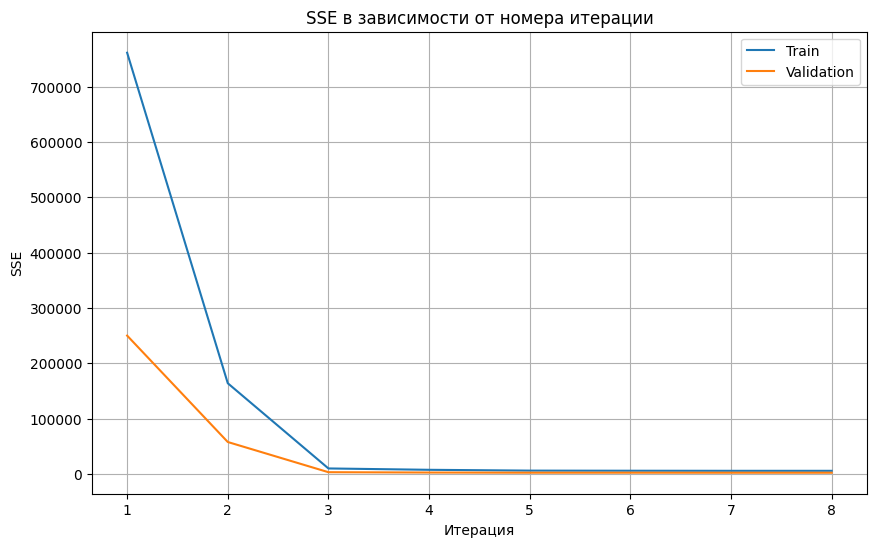

In [5]:
import matplotlib.pyplot as plt

iterations = range(1, len(train_sse) + 1)

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_sse, label="Train")
plt.plot(iterations, val_sse, label="Validation")

plt.xlabel("Итерация")
plt.ylabel("SSE")
plt.title("SSE в зависимости от номера итерации")

plt.legend()
plt.grid(True)
plt.show()

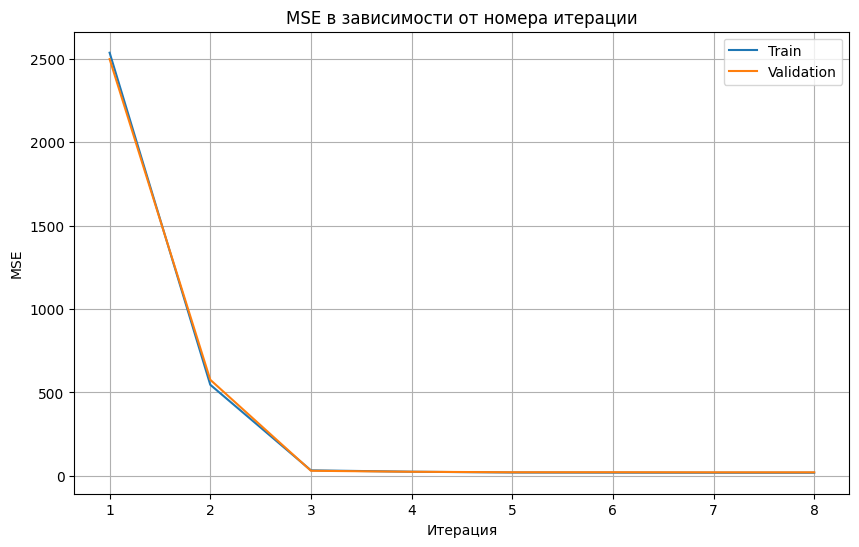

In [6]:
iterations = range(1, len(train_mse) + 1)

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_mse, label="Train")
plt.plot(iterations, val_mse, label="Validation")

plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.title("MSE в зависимости от номера итерации")

plt.legend()
plt.grid(True)
plt.show()

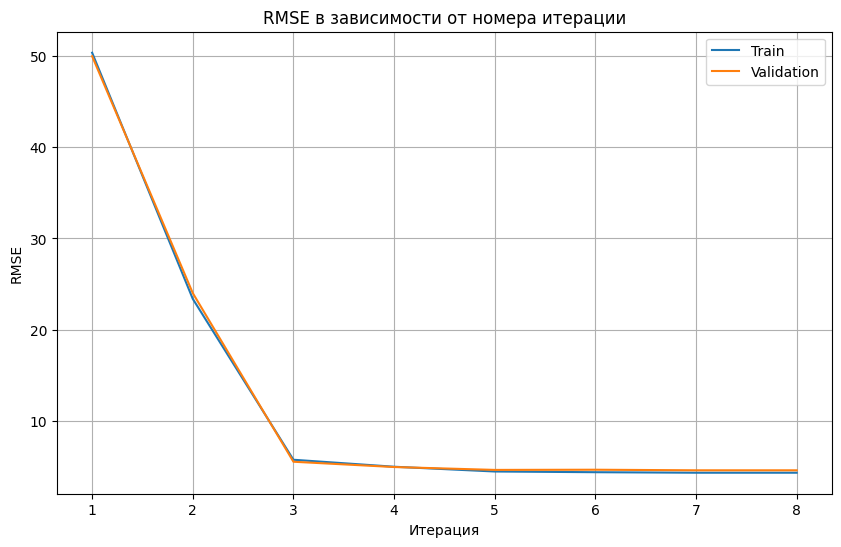

In [7]:
iterations = range(1, len(train_rmse) + 1)

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_rmse, label="Train")
plt.plot(iterations, val_rmse, label="Validation")

plt.xlabel("Итерация")
plt.ylabel("RMSE")
plt.title("RMSE в зависимости от номера итерации")

plt.legend()
plt.grid(True)
plt.show()

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

## Ответ(вопрос 2):
По графикам видно, что модель сходится(обучилась) и даёт нужный прогноз на 8 итерации обучения, с выбранными гиперпараммметрами.

Так же можно сказать что нет недообучения и нет переобучения

#### Вопрос 3.

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

## Ответ(вопрос 3):
1) При недообученной модели линия ошибки по train и val выборке не сойдётся к линии оптимума и такми образом модель не подберёт нужные веса. Недообученность происходит когда модель не подходит для определённой задачи или когда не хватило эпох/неправильно подобраны гиперпараметры. К примеру с моих графиков, модель была бы недообучена если бы она остановила своё обучение на 2 эпохе, когда тренд снижения ошибки ещё есть.

2) При обученной модели train и val сходятся и уходят в так называемое плато, когда и train и val предсказываются с +- одинаковой ошибкой. Пример: мой график.

3) При переобучении модели ошибка val увеличивается, train уменьшается. Растёт зазор между train и val. Таким образум переобучение это когда модель слишком хорошо обучается находить ответы под тренировочную выборку, при этом ограничивая себя в вариативности. Но когда ей подают новые данные, она сильно ошибается.

#### Шаг 6. Применение модели на тестовой выборке

In [8]:
y_test_pred = X_test_np @ weight

#### Шаг 7. RMSE на тестовой выборке

In [9]:
from sklearn.metrics import root_mean_squared_error

rmse_test = root_mean_squared_error(y_test_pred, y_test)
print(rmse_test)

4.831564674023429


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

## Ответ(вопрос 4):
RMSE = 4.83 говорит о том, что в среднем модель ошибается на 4.83 минуты в своём прогнозе на тестовой выборке.